# MNIST MLP3 — Muon + auxiliary AdamW baseline

This is the reference Muon control. `fc1.weight` and `fc2.weight` use Muon with step-level warm-up/cosine decay from 0.02 to 0.002, momentum 0.95, Nesterov, five Newton–Schulz iterations, and weight decay 0.01. `fc3.weight` and all biases use auxiliary AdamW from 3e-4 to 3e-5 with betas (0.90, 0.95). The historical file and directory key remains `sgd_momentum_muon` only for compatibility.

Results are written beneath the versioned suite directory `mnist_mlp3_recipe_v3`. Legacy unversioned result directories—including the unstable 20-epoch Muon + auxiliary-SGD run—are ignored and cannot be resumed or compared accidentally.

The data policy is 55,000 optimization examples, a fixed 5,000-example validation split, and the official test set used only for monitoring. At epoch zero and every epoch the code runs `watcher.analyze(ERG=True, randomize=True)` and retains direct `alpha`, `ERG_gap`, and `num_traps`.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = None
for path in [Path.cwd(), *Path.cwd().parents]:
    candidate = path / 'baseline'
    if (candidate / 'rg_baselines').is_dir():
        ROOT = candidate
        break
    if (path / 'rg_baselines').is_dir():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError('Run from a current clone of CalculatedContent/rg_optimizers.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rg_baselines import (
    BaselineConfig,
    DEFAULT_BASELINE_SEEDS,
    MNIST_REFERENCE_RECIPE_VERSION,
    MNIST_REFERENCE_SUITE_SLUG,
    plot_all_replicates,
    run_baseline_replicates,
)

BASE_RUN_ROOT = Path(
    os.environ.get('RG_BASELINE_RUN_ROOT', ROOT / 'runs')
).expanduser().resolve()
RUN_ROOT = BASE_RUN_ROOT / MNIST_REFERENCE_SUITE_SLUG
DATA_DIR = Path(
    os.environ.get('RG_BASELINE_DATA_DIR', ROOT / 'data')
).expanduser().resolve()
for directory in (BASE_RUN_ROOT, RUN_ROOT, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
CONFIG = BaselineConfig(
    optimizer='sgd_momentum_muon',
    epochs=30,
    validation_size=5_000,
    muon_parameter_names=('fc1.weight', 'fc2.weight'),
    muon_learning_rate=0.02,
    muon_min_learning_rate=0.002,
    muon_warmup_epochs=2,
    muon_momentum=0.95,
    muon_nesterov=True,
    muon_weight_decay=0.01,
    muon_newton_schulz_steps=5,
    muon_aux_learning_rate=3e-4,
    muon_aux_min_learning_rate=3e-5,
    muon_aux_beta1=0.90,
    muon_aux_beta2=0.95,
    muon_aux_weight_decay=0.01,
    ww_randomize=True,
    save_epoch_checkpoints=True,
)
CONFIG.validate()
if CONFIG.recipe_version != MNIST_REFERENCE_RECIPE_VERSION:
    raise RuntimeError(
        f'Notebook expects MNIST recipe v{MNIST_REFERENCE_RECIPE_VERSION}; '
        f'loaded v{CONFIG.recipe_version}. Pull current main before running.'
    )
assert CONFIG.muon_aux_learning_rate == 3e-4
assert CONFIG.muon_weight_decay == 0.01

SEEDS = DEFAULT_BASELINE_SEEDS
assert len(SEEDS) == 3 and len(set(SEEDS)) == 3
RUN_DIR = RUN_ROOT / CONFIG.run_slug
PLOT_DIR = RUN_DIR / 'plots'
for directory in (RUN_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

LEGACY_DIR = BASE_RUN_ROOT / CONFIG.run_slug
if LEGACY_DIR.is_dir() and LEGACY_DIR != RUN_DIR:
    print('Ignoring legacy unversioned artifacts:', LEGACY_DIR)
print('MNIST reference recipe:', CONFIG.recipe_version)
print('optimizer implementation:', CONFIG.optimizer_label)
print('versioned suite root:', RUN_ROOT)
print('current run directory:', RUN_DIR)
display(pd.DataFrame([CONFIG.__dict__]))


MNIST reference recipe: 3
optimizer implementation: Muon + auxiliary AdamW
versioned suite root: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3
current run directory: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/sgd_momentum_muon


,optimizer,recipe_version,initialization,seed,epochs,batch_size,validation_size,split_seed,num_workers,grad_clip_norm,...,muon_aux_beta1,muon_aux_beta2,muon_aux_eps,muon_aux_weight_decay,ww_min_evals,ww_max_evals,ww_svd_method,ww_randomize,save_epoch_checkpoints,strict_metrics
0,sgd_momentum_muon,3,kaiming_uniform_relu_hidden_xavier_uniform_hea...,1337,30,128,5000,20260807,0,1.0,...,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True


## Run or resume three complete trajectories

The runner asserts and records the Muon/AdamW parameter assignment. Only checkpoints carrying the current recipe fingerprint inside the versioned suite directory can resume.



=== Muon + auxiliary AdamW: replicate 1/3, seed=1337 ===


PyTorch is available but CUDA is not. Defaulting to NumPy for SVD


Import error , reetting to svd accurate methods


Running on macOS.
Running on macOS.


SMALL N PL FIT


...

epoch=028 | Muon + auxiliary AdamW | lr=2.226e-03 | train=1.0000 | val=0.9890 | test=0.9857


SMALL N PL FIT


epoch=029 | Muon + auxiliary AdamW | lr=2.057e-03 | train=1.0000 | val=0.9892 | test=0.9860


SMALL N PL FIT


epoch=030 | Muon + auxiliary AdamW | lr=2.000e-03 | train=1.0000 | val=0.9902 | test=0.9861


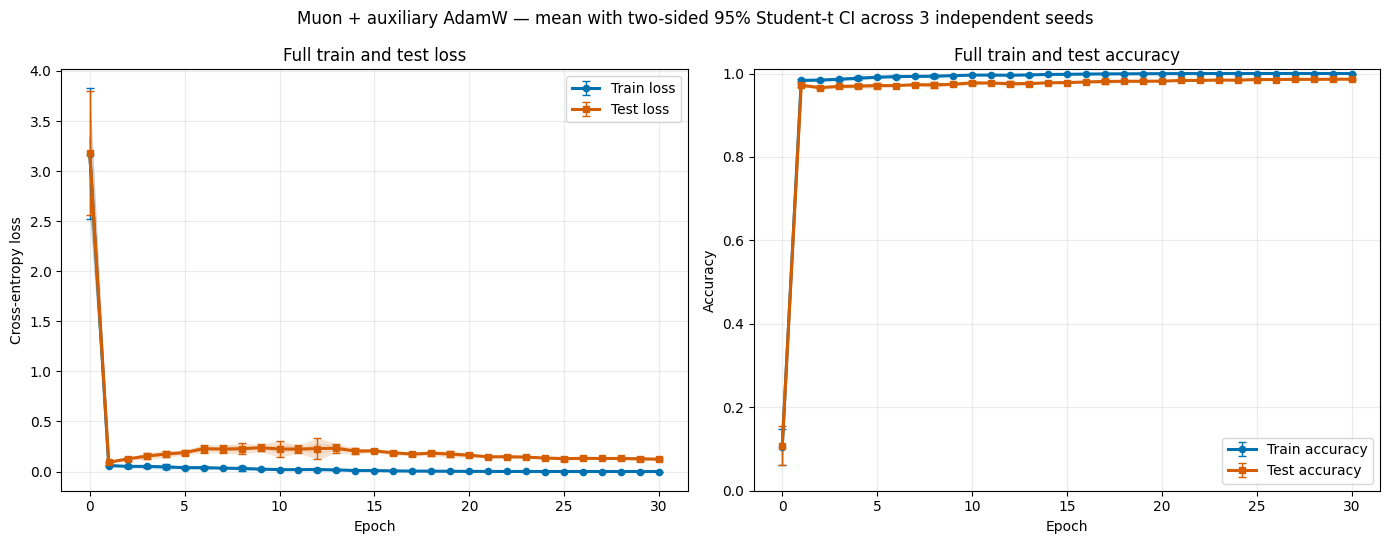

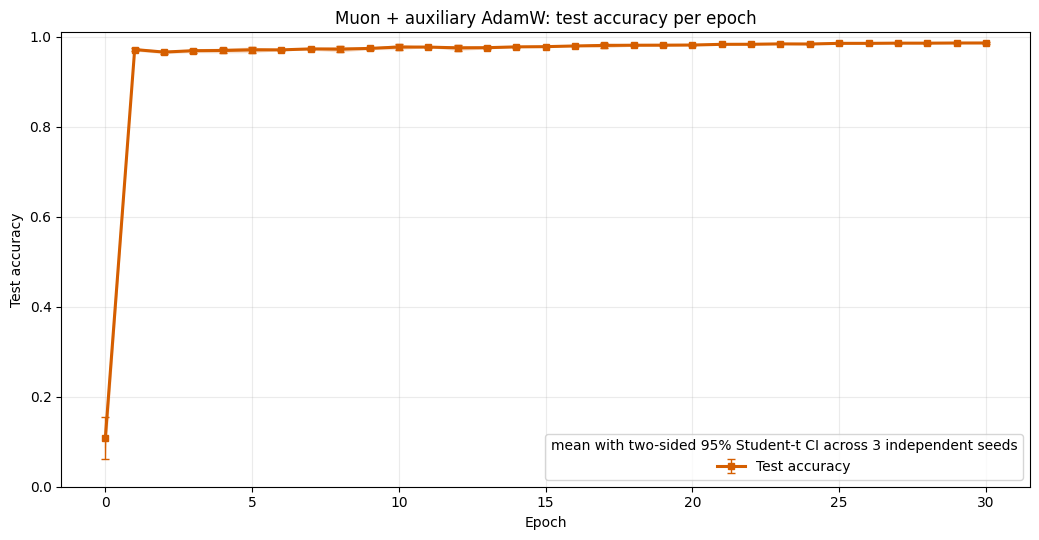

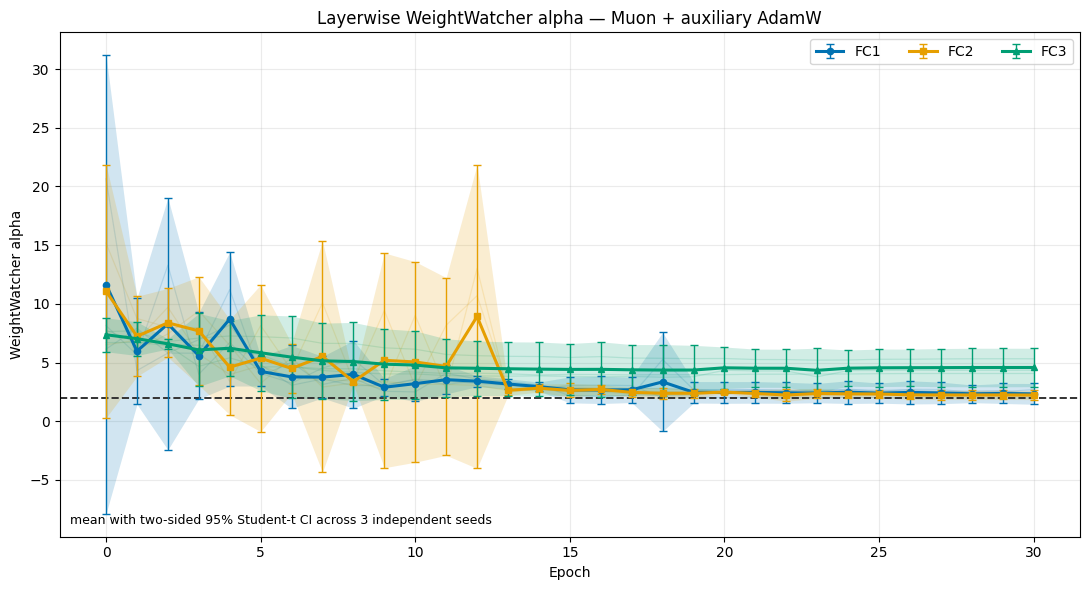

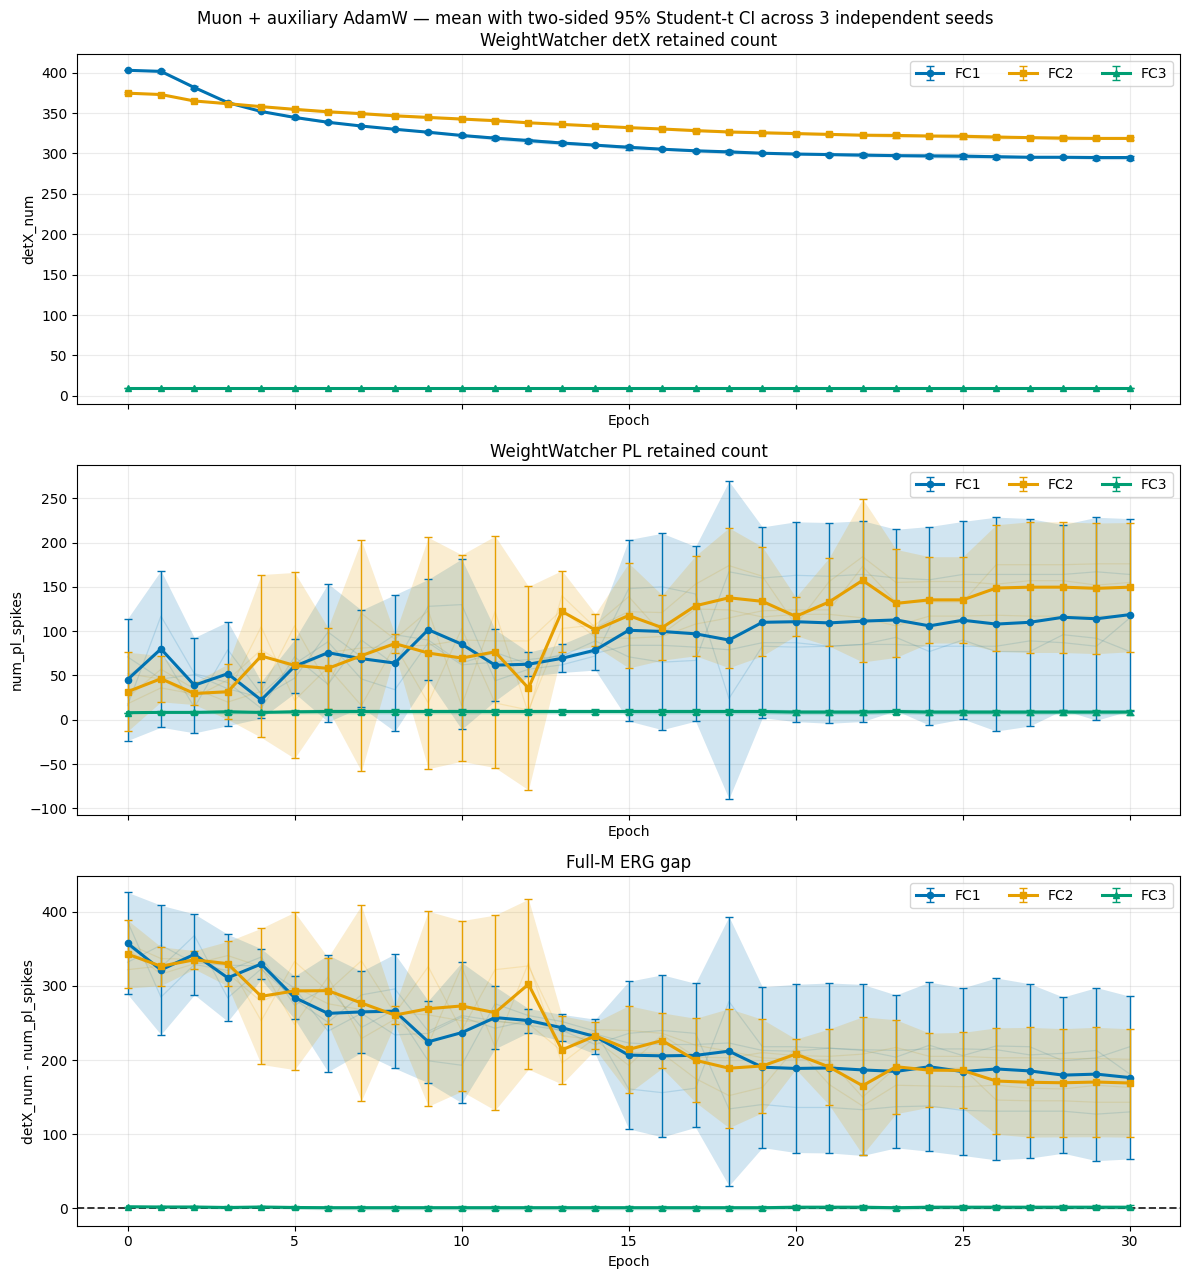

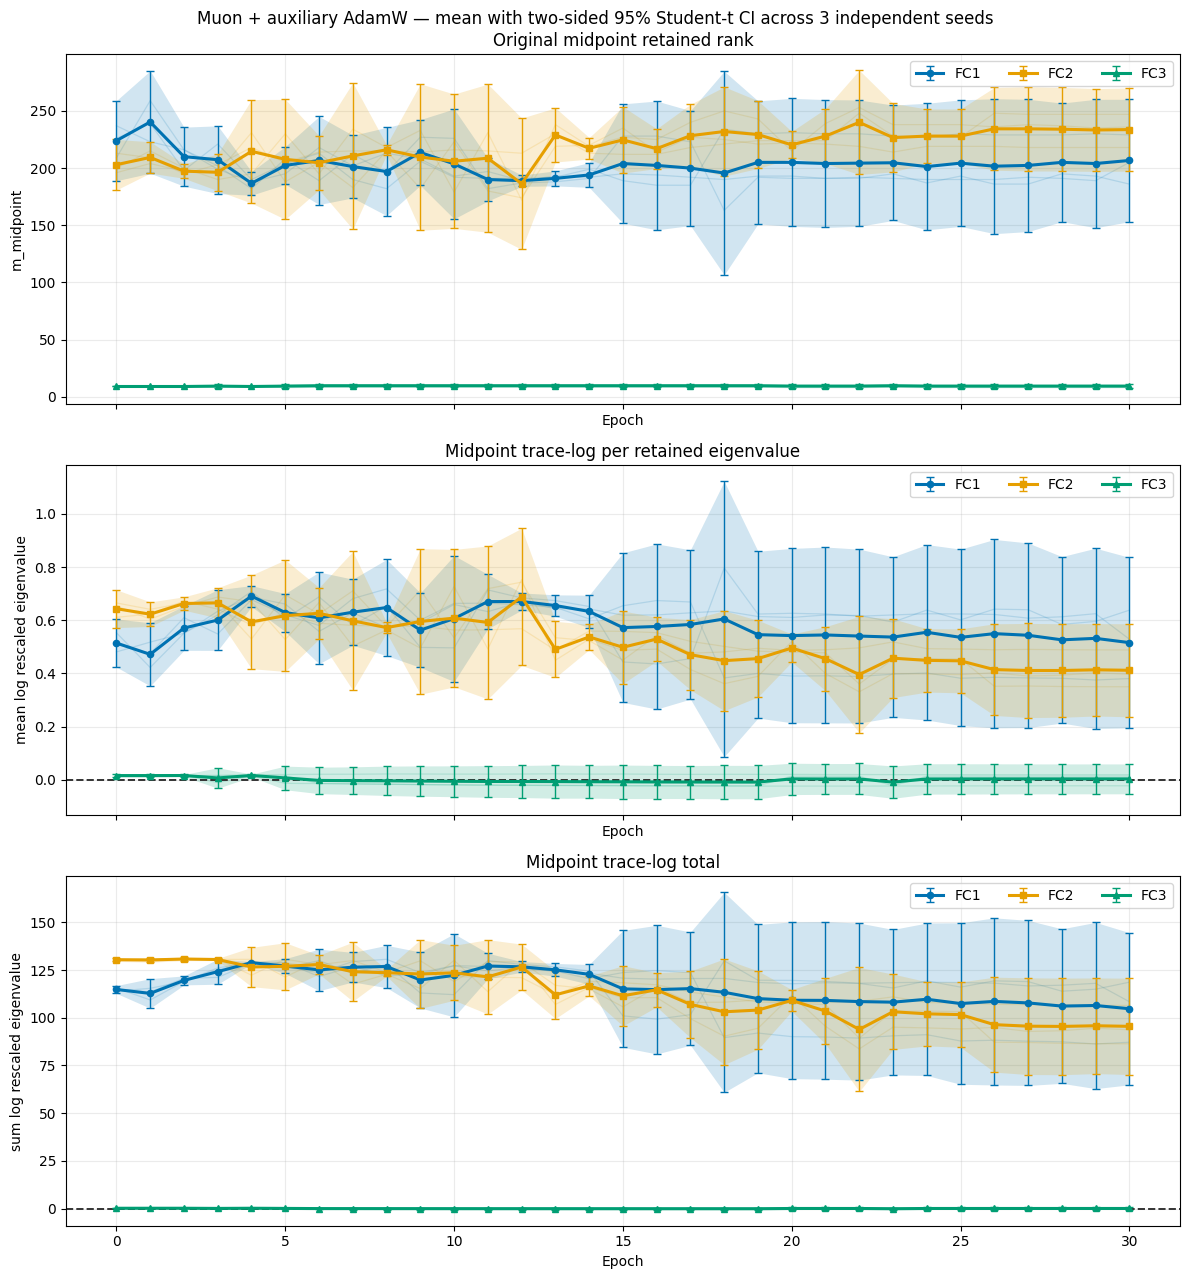

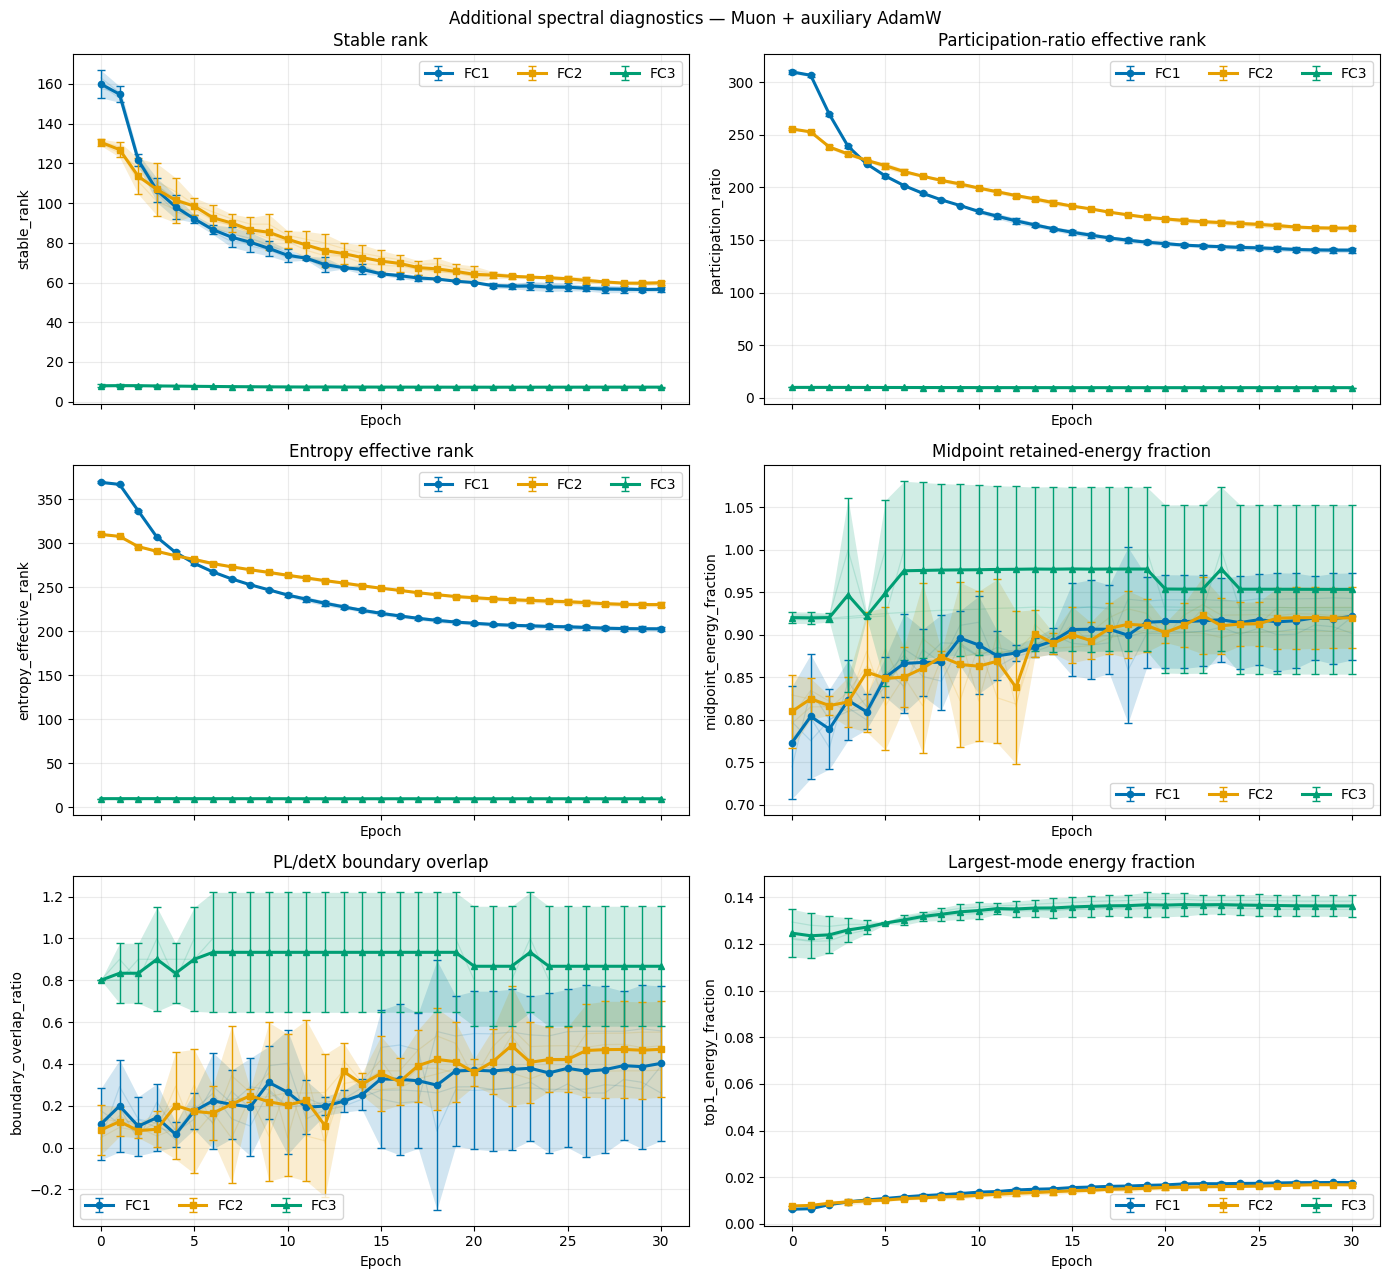

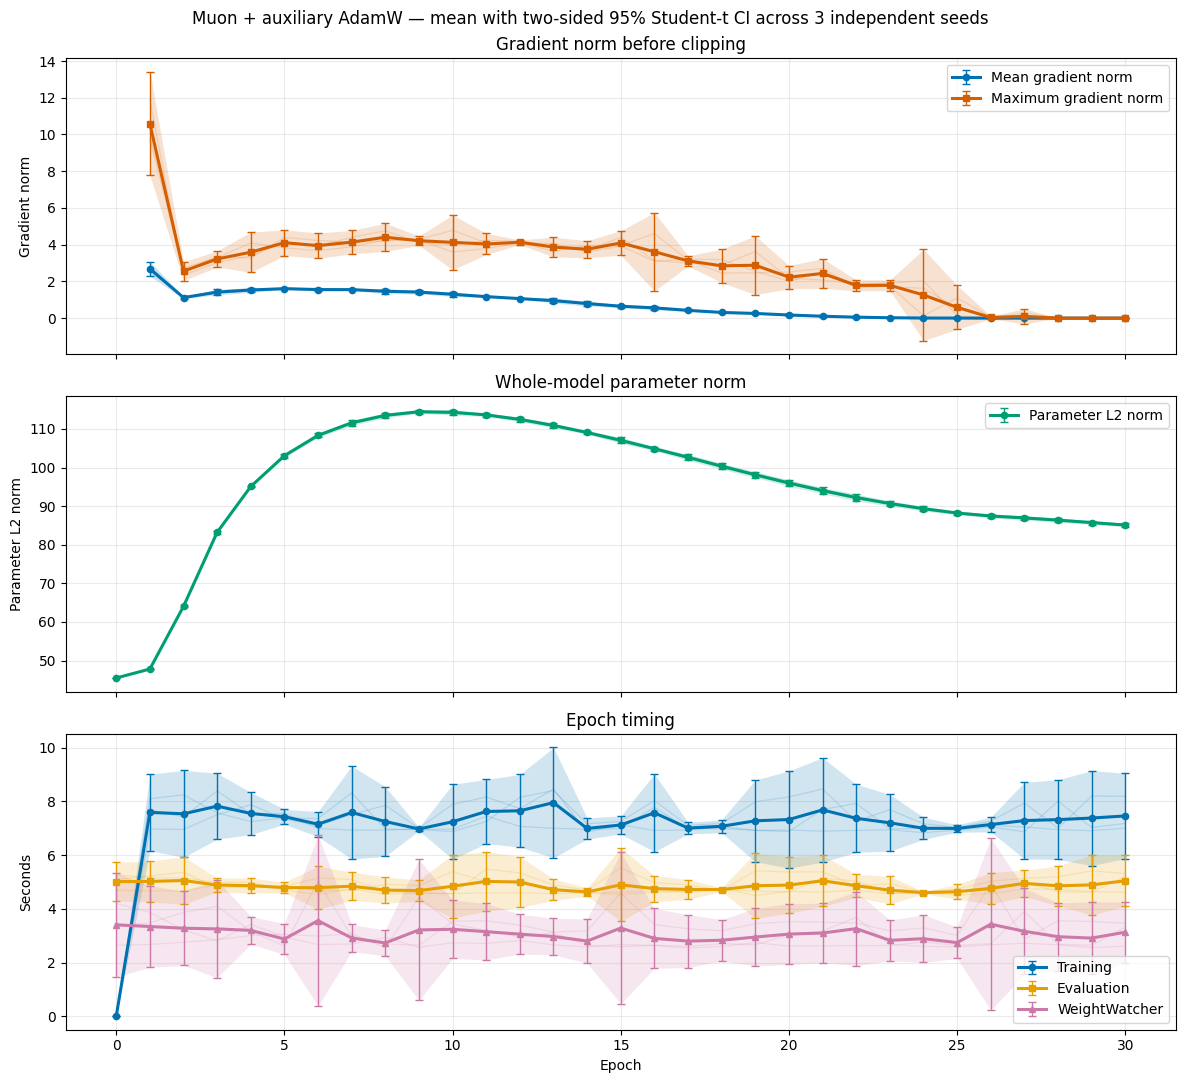

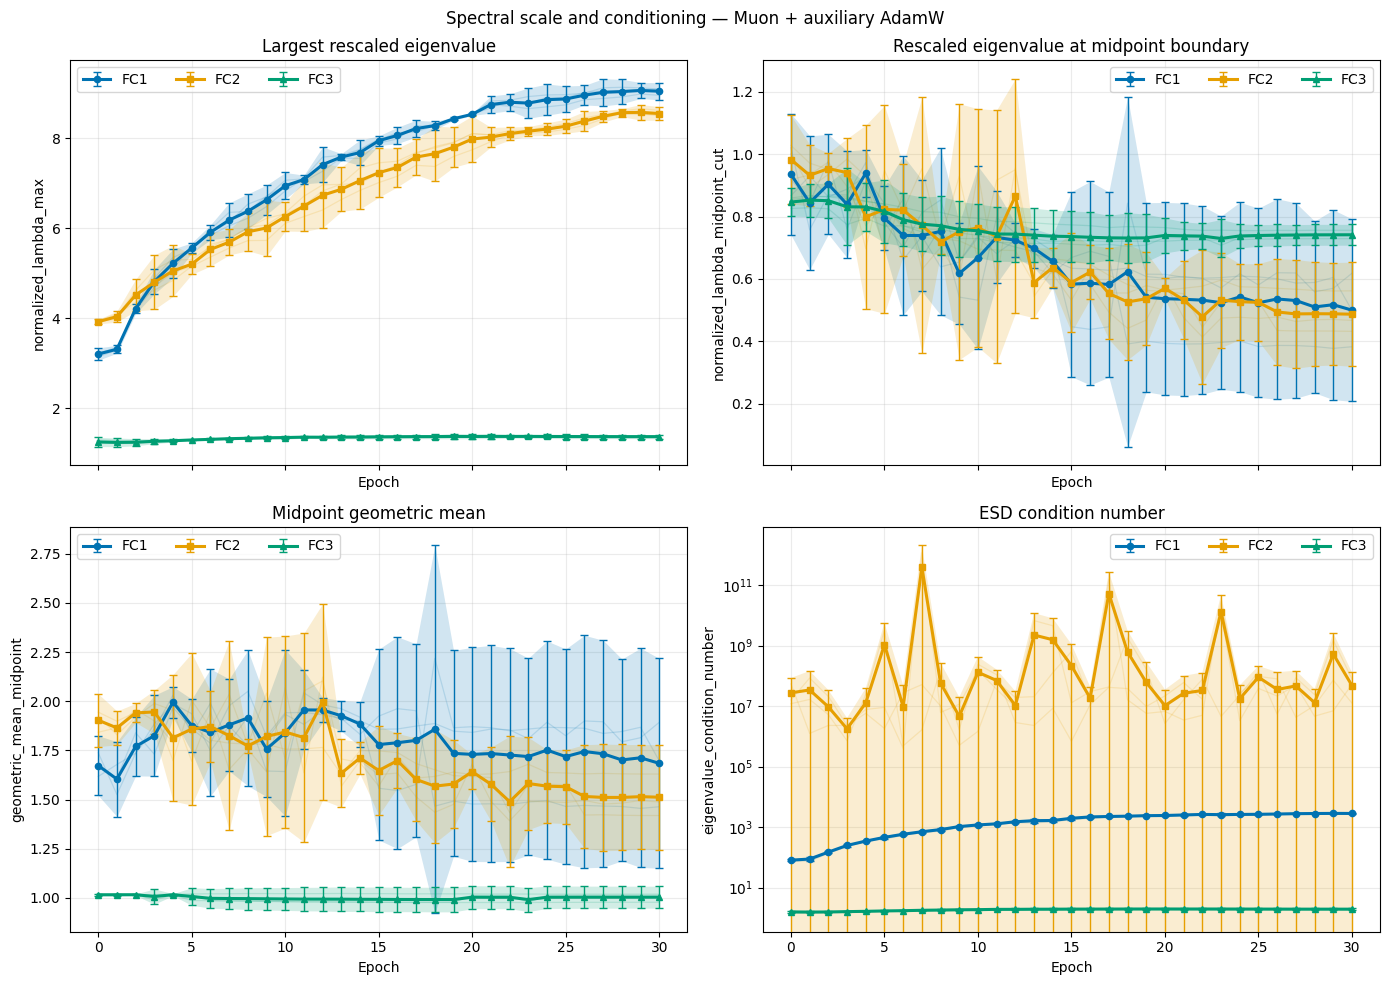

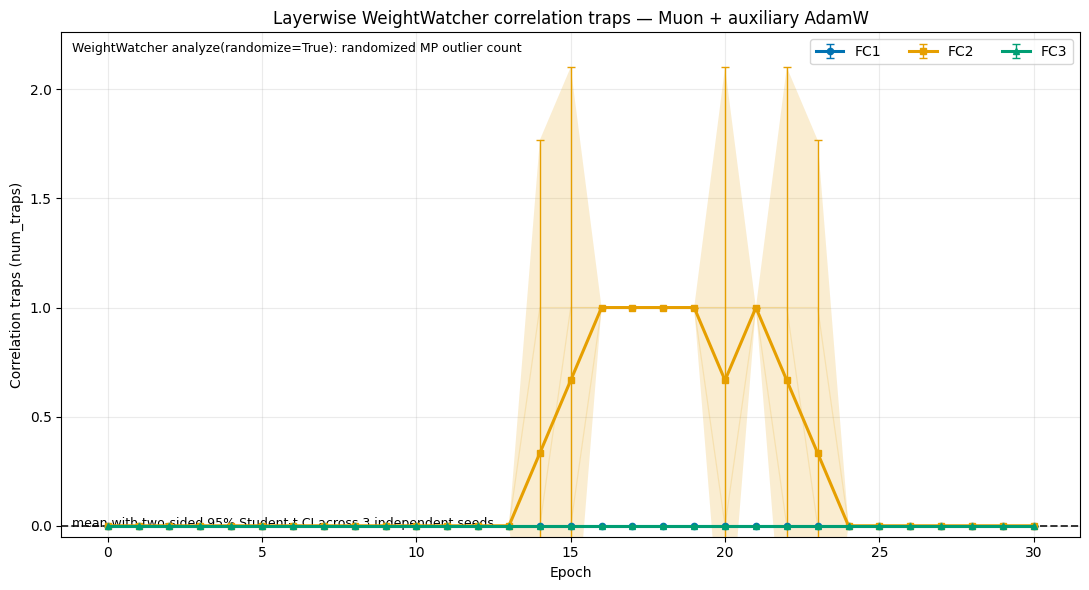

,run,epoch,group_index,kind,names,parameter_tensors,parameter_count,learning_rate,momentum,beta1,beta2,weight_decay,nesterov,seed,replicate,optimizer,optimizer_label
0,Muon + auxiliary AdamW,0,0,muon,fc1.weight|fc2.weight,2,663552,2.325581e-05,0.95,NaN,NaN,0.01,True,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
1,Muon + auxiliary AdamW,0,1,adamw_decay,fc3.weight,1,5120,3.488372e-07,NaN,0.9,0.95,0.01,False,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
2,Muon + auxiliary AdamW,0,2,adamw_no_decay,fc1.bias|fc2.bias|fc3.bias,3,1034,3.488372e-07,NaN,0.9,0.95,0.00,False,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
3,Muon + auxiliary AdamW,1,0,muon,fc1.weight|fc2.weight,2,663552,1.000000e-02,0.95,NaN,NaN,0.01,True,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
4,Muon + auxiliary AdamW,1,1,adamw_decay,fc3.weight,1,5120,1.500000e-04,NaN,0.9,0.95,0.01,False,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
5,Muon + auxiliary AdamW,1,2,adamw_no_decay,fc1.bias|fc2.bias|fc3.bias,3,1034,1.500000e-04,NaN,0.9,0.95,0.00,False,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
6,Muon + auxiliary AdamW,2,0,muon,fc1.weight|fc2.weight,2,663552,2.000000e-02,0.95,NaN,NaN,0.01,True,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
7,Muon + auxiliary AdamW,2,1,adamw_decay,fc3.weight,1,5120,3.000000e-04,NaN,0.9,0.95,0.01,False,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
8,Muon + auxiliary AdamW,2,2,adamw_no_decay,fc1.bias|fc2.bias|fc3.bias,3,1034,3.000000e-04,NaN,0.9,0.95,0.00,False,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW
9,Muon + auxiliary AdamW,3,0,muon,fc1.weight|fc2.weight,2,663552,1.994366e-02,0.95,NaN,NaN,0.01,True,1337,0,sgd_momentum_muon,Muon + auxiliary AdamW


In [3]:
suite = run_baseline_replicates(
    CONFIG,
    seeds=SEEDS,
    data_dir=DATA_DIR,
    output_dir=RUN_DIR,
    progress=True,
    confidence=0.95,
    resume=True,
    overwrite=False,
)
assert suite.config_template.recipe_version == MNIST_REFERENCE_RECIPE_VERSION
assert set(suite.optimizer_groups['kind']) == {
    'muon', 'adamw_decay', 'adamw_no_decay'
}
plot_all_replicates(suite, output_dir=PLOT_DIR, show=True)
display(
    suite.optimizer_groups.sort_values(
        ['seed', 'epoch', 'group_index']
    ).head(12)
)


## Train, validation, test, and learning-rate trajectories

The primary Muon and auxiliary AdamW schedules are logged separately. Validation loss is the only checkpoint-selection signal.


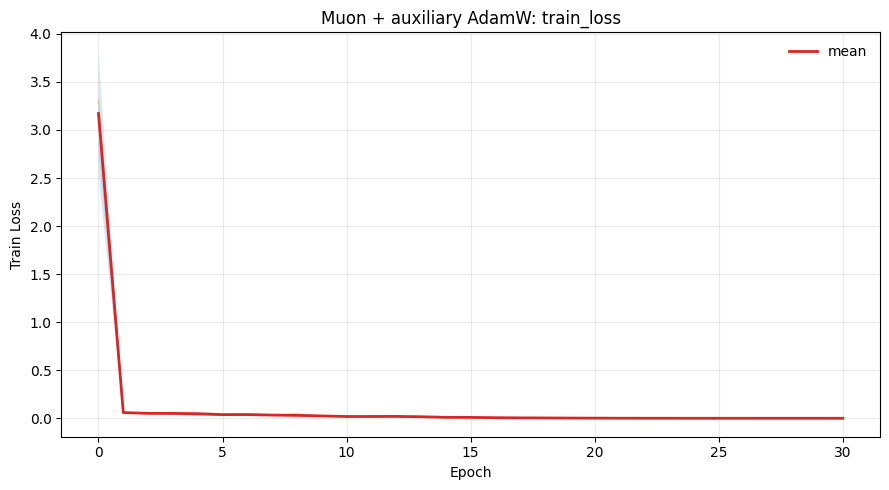

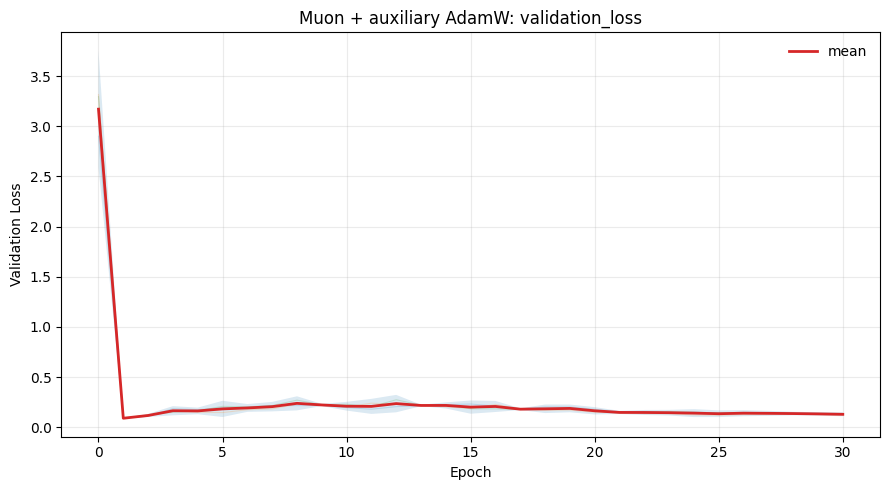

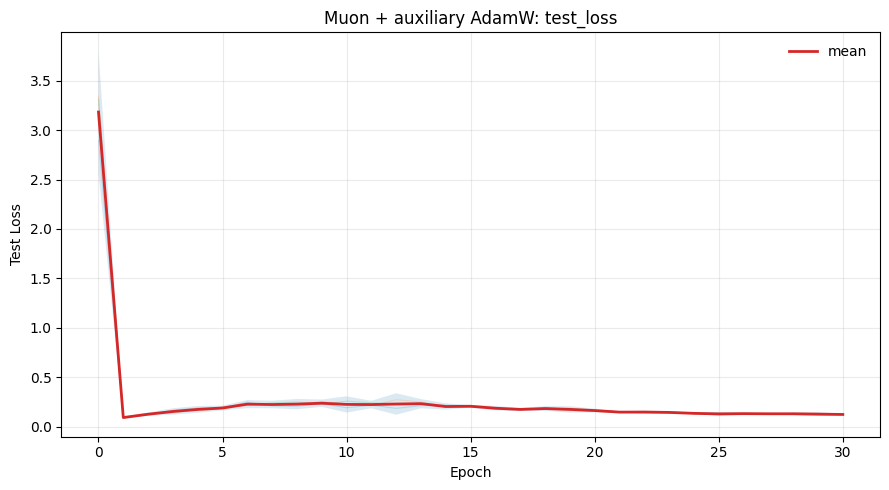

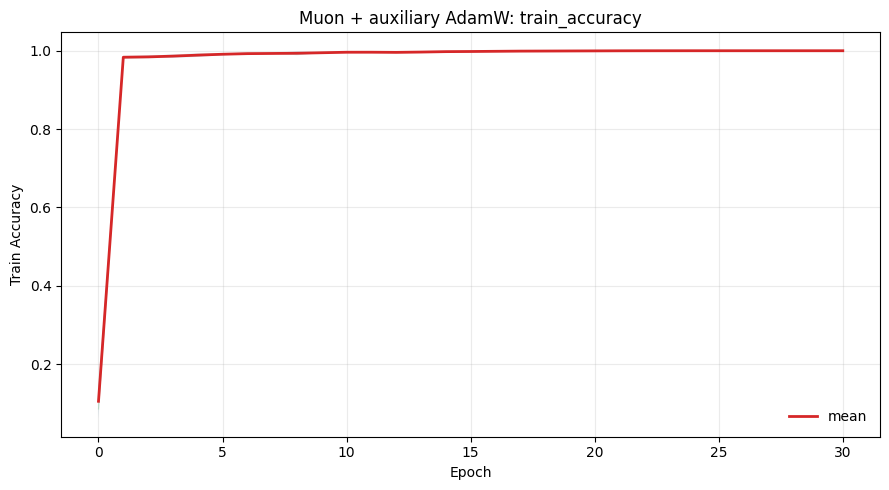

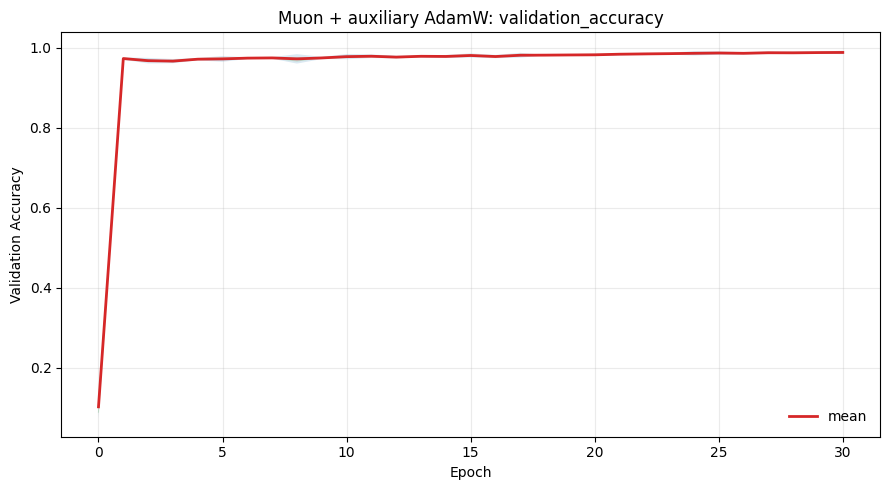

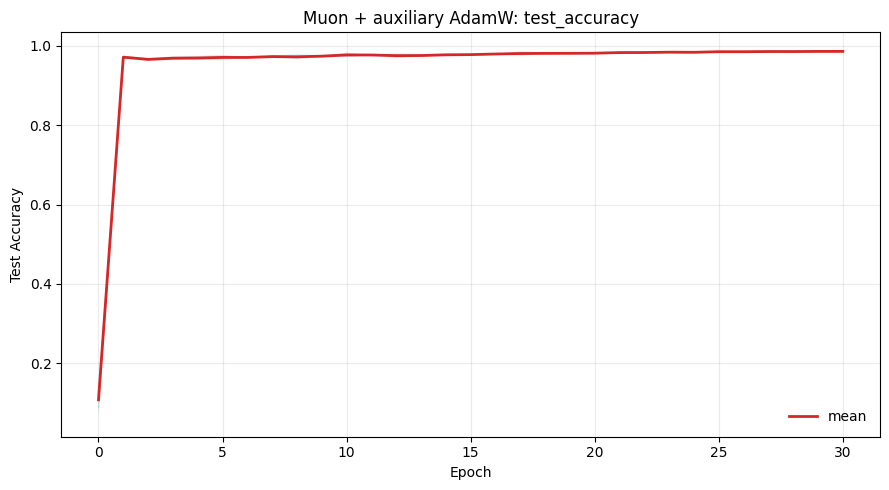

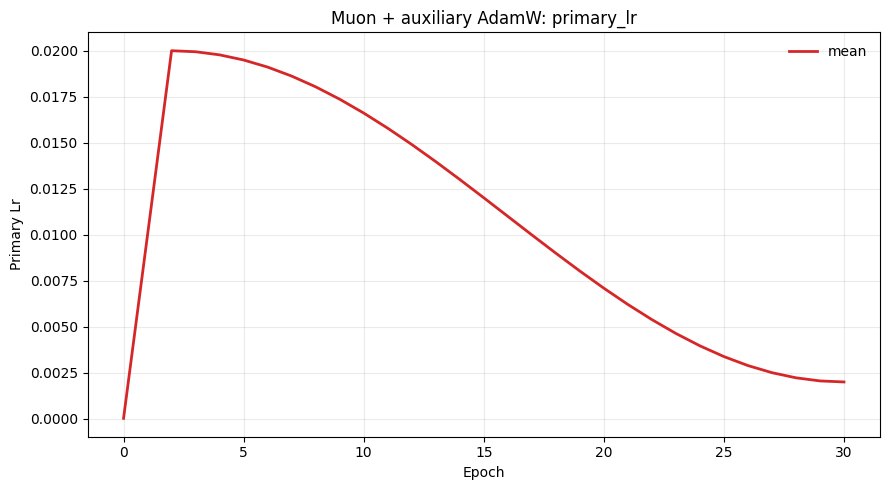

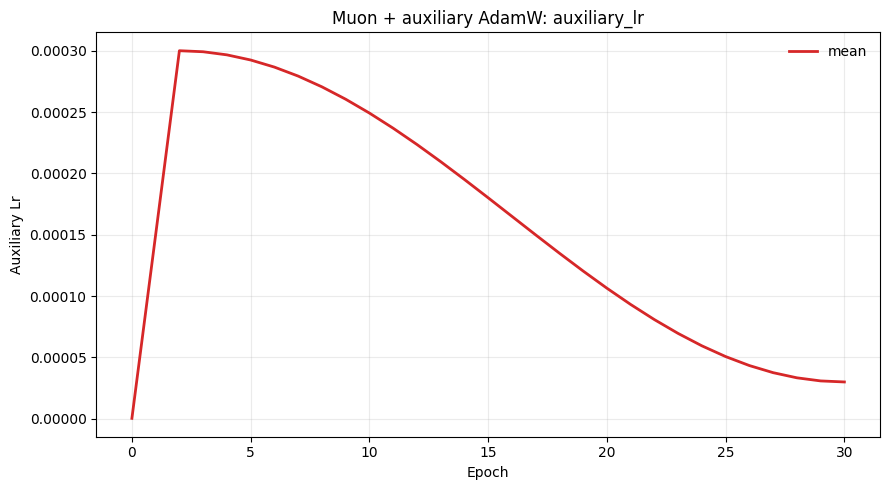

,run,optimizer,optimizer_label,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
7,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,0,auxiliary_lr,3,3.488372e-07,6.483745e-23,3.743392e-23,0.95,4.302653,1.610652e-22,3.488372e-07,3.488372e-07,3.488372e-07,3.488372e-07
24,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,1,auxiliary_lr,3,1.500000e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,1.500000e-04,1.500000e-04,1.500000e-04,1.500000e-04
46,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,2,auxiliary_lr,3,3.000000e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,3.000000e-04,3.000000e-04,3.000000e-04,3.000000e-04
68,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,3,auxiliary_lr,3,2.991549e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.991549e-04,2.991549e-04,2.991549e-04,2.991549e-04
90,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,4,auxiliary_lr,3,2.966225e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.966225e-04,2.966225e-04,2.966225e-04,2.966225e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,26,validation_loss,3,1.411825e-01,1.218052e-02,7.032424e-03,0.95,4.302653,3.025808e-02,1.109244e-01,1.714406e-01,1.273381e-01,1.502529e-01
590,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,27,validation_loss,3,1.396193e-01,1.002382e-02,5.787255e-03,0.95,4.302653,2.490055e-02,1.147187e-01,1.645198e-01,1.280460e-01,1.455547e-01
612,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,28,validation_loss,3,1.374228e-01,7.129760e-03,4.116369e-03,0.95,4.302653,1.771131e-02,1.197115e-01,1.551341e-01,1.300228e-01,1.442475e-01
634,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,29,validation_loss,3,1.342003e-01,6.558061e-03,3.786298e-03,0.95,4.302653,1.629113e-02,1.179092e-01,1.504915e-01,1.278066e-01,1.409112e-01


In [4]:
for metric in [
    'train_loss', 'validation_loss', 'test_loss',
    'train_accuracy', 'validation_accuracy', 'test_accuracy',
    'primary_lr', 'auxiliary_lr',
]:
    summary = suite.performance_summary[
        suite.performance_summary['metric'].eq(metric)
    ].sort_values('epoch')
    if summary.empty:
        continue
    figure, axis = plt.subplots(figsize=(9, 5))
    for seed, run in suite.performance.groupby('seed'):
        axis.plot(run['epoch'], run[metric], alpha=0.18, linewidth=0.8)
    axis.plot(summary['epoch'], summary['mean'], linewidth=2.0, label='mean')
    axis.fill_between(
        summary['epoch'], summary['ci_low'], summary['ci_high'], alpha=0.16
    )
    axis.set(
        xlabel='Epoch',
        ylabel=metric.replace('_', ' ').title(),
        title=f'{CONFIG.optimizer_label}: {metric}',
    )
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
    figure.tight_layout()
    figure.savefig(
        PLOT_DIR / f'{metric}_95ci.png', dpi=170, bbox_inches='tight'
    )
    plt.show()

display(
    suite.performance_summary[
        suite.performance_summary['metric'].isin([
            'train_loss', 'validation_loss', 'test_loss',
            'train_accuracy', 'validation_accuracy', 'test_accuracy',
            'primary_lr', 'auxiliary_lr',
        ])
    ].sort_values(['metric', 'epoch'])
)


## Layerwise WeightWatcher diagnostics


In [5]:
required = [
    'alpha', 'ERG_gap', 'num_traps',
    'm_midpoint', 'trace_log_midpoint_per_eval',
]
rows = suite.spectral_summary[
    suite.spectral_summary['metric'].isin(required)
].sort_values(['metric', 'layer', 'epoch'])
assert rows['n'].eq(3).all()
display(rows)


,run,optimizer,optimizer_label,layer,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
4,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,0,ERG_gap,3,357.666667,27.682726,15.982629,0.95,4.302653,68.767704,288.898962,426.434371,332.000000,387.000000
33,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,1,ERG_gap,3,321.666667,35.118846,20.275875,0.95,4.302653,87.240049,234.426617,408.906716,285.000000,355.000000
62,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,2,ERG_gap,3,342.666667,21.962089,12.679818,0.95,4.302653,54.556852,288.109814,397.223519,329.000000,368.000000
91,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,3,ERG_gap,3,311.000000,23.643181,13.650397,0.95,4.302653,58.732917,252.267083,369.732917,284.000000,328.000000
120,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,4,ERG_gap,3,329.666667,8.326664,4.807402,0.95,4.302653,20.684580,308.982087,350.351247,323.000000,339.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2558,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc3,26,trace_log_midpoint_per_eval,3,0.003078,0.022849,0.013192,0.95,4.302653,0.056760,-0.053682,0.059839,-0.023117,0.018904
2587,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc3,27,trace_log_midpoint_per_eval,3,0.003077,0.022696,0.013103,0.95,4.302653,0.056379,-0.053303,0.059456,-0.022947,0.018765
2616,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc3,28,trace_log_midpoint_per_eval,3,0.003093,0.022661,0.013083,0.95,4.302653,0.056292,-0.053199,0.059385,-0.022892,0.018748
2645,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc3,29,trace_log_midpoint_per_eval,3,0.003111,0.022644,0.013073,0.95,4.302653,0.056250,-0.053139,0.059360,-0.022857,0.018737


In [6]:
required_paths = [
    RUN_DIR / 'performance_by_epoch_and_seed.csv',
    RUN_DIR / 'spectral_metrics_by_epoch_layer_and_seed.csv',
    RUN_DIR / 'performance_summary_95ci.csv',
    RUN_DIR / 'spectral_summary_95ci.csv',
    RUN_DIR / 'replicate_manifest.json',
    PLOT_DIR / '7_layerwise_weightwatcher_num_traps_95ci.png',
]
for seed in SEEDS:
    seed_dir = RUN_DIR / 'seeds' / f'seed_{seed}'
    required_paths.extend([
        seed_dir / 'checkpoint_latest.pt',
        seed_dir / 'checkpoint_best.pt',
        seed_dir / 'final_state.pt',
        seed_dir / 'test_results.json',
        seed_dir / 'run_complete.json',
    ])
missing = [path for path in required_paths if not path.is_file()]
if missing:
    raise RuntimeError(
        'Missing required artifacts:\n' + '\n'.join(map(str, missing))
    )
print('verified artifacts:', len(required_paths))


verified artifacts: 21
